In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [2]:
from langchain_groq import ChatGroq

model = ChatGroq(model="openai/gpt-oss-20b")

c:\ProgramData\miniconda3\envs\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Summarization Middleware

In [3]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, SystemMessage

#### Message based summarization

In [4]:
agent = create_agent(
    model=model,
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model=model,
            trigger=("messages", 10),
            keep=("messages", 4)
        )
    ]
)

In [5]:
config = {
    "configurable" : {
        "thread_id": "test_1"
    }
}

In [6]:
questions = [
    "What is 2+2",
    "What is 10*2",
    "What is 100/4",
    "What is 5-2",
    "What is 2*2",
    "What is 3*3"
]

In [7]:
for question in questions:
    response = agent.invoke({
        'messages': [HumanMessage(content=question)]
    }, config)
    print(f"Messages : {response}")
    print(f"Message Length : {len(response['messages'])}")

Messages : {'messages': [HumanMessage(content='What is 2+2', additional_kwargs={}, response_metadata={}, id='7fa8415b-a605-43b7-abd4-f615792e4d2c'), AIMessage(content='4', additional_kwargs={'reasoning_content': 'The user asks: "What is 2+2". Straightforward. The answer: 4.'}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 77, 'total_tokens': 109, 'completion_time': 0.032852657, 'completion_tokens_details': {'reasoning_tokens': 22}, 'prompt_time': 0.003683399, 'prompt_tokens_details': None, 'queue_time': 0.049841081, 'total_time': 0.036536056}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_80501ff3a1', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019dbeb1-91a1-7260-add8-e33df1a942e3-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 77, 'output_tokens': 32, 'total_tokens': 109, 'output_token_details': {'reasoning': 22}})]}
Message Length : 2
Messages : 

#### Token size based

In [8]:
from langchain_core.tools import tool

@tool
def search_hotels(city: str) -> str:
    """Search hotels - returns long response to use more tokens."""
    return f"""Hotels in {city}:
    1. Grand Hotel - 5 star, $350/night, spa, pool, gym
    2. City Inn - 4 star, $180/night, business center
    3. Budget Stay - 3 star, $75/night, free wifi"""

In [9]:
agent = create_agent(
    model=model,
    tools=[search_hotels],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model=model,
            trigger=("tokens",550),
            keep=("tokens",200),
        )
    ]
)

In [10]:
def count_tokens(messages):
    total_chars = sum(len(str(m.content)) for m in messages)
    return total_chars // 4  # 4 chars ≈ 1 token

In [11]:
cities = ["Paris", "London", "Tokyo", "New York", "Dubai", "Singapore"]

for city in cities:
    response = agent.invoke(
        {"messages": [HumanMessage(content=f"Find hotels in {city}")]},
        config=config
    )
    
    tokens = count_tokens(response["messages"])
    print(f"{city}: ~{tokens} tokens, {len(response['messages'])} messages")
    print(f"{(response['messages'])}")

Paris: ~205 tokens, 4 messages
[HumanMessage(content='Find hotels in Paris', additional_kwargs={}, response_metadata={}, id='c86f2f2b-28a6-4b70-b410-bdd4207b4680'), AIMessage(content='', additional_kwargs={'reasoning_content': 'The user wants "Find hotels in Paris". We have a function search_hotels that takes city. We should call it.', 'tool_calls': [{'id': 'fc_7231be6e-5a7e-4a60-a7e6-831ba153fecb', 'function': {'arguments': '{"city":"Paris"}', 'name': 'search_hotels'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 129, 'total_tokens': 179, 'completion_time': 0.054577698, 'completion_tokens_details': {'reasoning_tokens': 26}, 'prompt_time': 0.008671958, 'prompt_tokens_details': None, 'queue_time': 0.048675512, 'total_time': 0.063249656}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_80501ff3a1', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019dbe

#### Fraction based

In [12]:
@tool
def search_hotels(city: str) -> str:
    """Search hotels."""
    return f"Hotels in {city}: Grand Hotel $350, City Inn $180, Budget Stay $75"

# LOW fraction for testing!
agent = create_agent(
    model=model,
    tools=[search_hotels],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model=model,
            trigger=("fraction", 0.005),  # 0.5% = ~640 tokens
            keep=("fraction", 0.002),     # 0.2% = ~256 tokens
        ),
    ],
)

In [13]:
cities = ["Paris", "London", "Tokyo", "New York", "Dubai", "Singapore"]

for city in cities:
    response = agent.invoke(
        {"messages": [HumanMessage(content=f"Hotels in {city}")]},
        config=config
    )
    tokens = count_tokens(response["messages"])
    fraction = tokens / 128000
    print(f"{city}: ~{tokens} tokens ({fraction:.4%}), {len(response['messages'])} msgs")
    print(response['messages'])

Paris: ~248 tokens (0.1938%), 4 msgs
[HumanMessage(content='Hotels in Paris', additional_kwargs={}, response_metadata={}, id='26bd4bf3-c8ed-4531-bae6-c697b5cbc99d'), AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks "Hotels in Paris". We need to use the function search_hotels with city "Paris". Then respond with results.', 'tool_calls': [{'id': 'fc_cdc80619-d35f-466a-a112-54810d96ec62', 'function': {'arguments': '{"city":"Paris"}', 'name': 'search_hotels'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 52, 'prompt_tokens': 120, 'total_tokens': 172, 'completion_time': 0.054316596, 'completion_tokens_details': {'reasoning_tokens': 28}, 'prompt_time': 0.00680501, 'prompt_tokens_details': None, 'queue_time': 0.048816259, 'total_time': 0.061121606}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_c5a89987dc', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='l

### Human In the Loop

In [14]:
from langchain.agents.middleware import HumanInTheLoopMiddleware

In [15]:
def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

In [16]:
agent = create_agent(
    model=model,
    tools=[read_email_tool, send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool": {
                    "allowed_decisions": ["approve", "edit", "reject"]
                },
                "read_email_tool": False
            }
        )
    ]
)

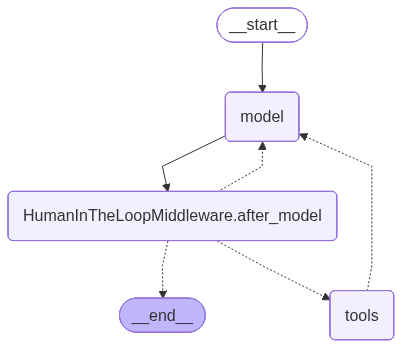

In [17]:
agent

##### Approve

In [18]:
config = {"configurable": {"thread_id": "test-approve"}}

result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'")]},
    config=config
)

result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='93275221-d8a3-4790-a336-e115c129faa1'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to call the send_email_tool function.', 'tool_calls': [{'id': 'fc_096d1fcf-5b20-41bf-b699-d3738c661109', 'function': {'arguments': '{"body":"How are you?","recipient":"john@test.com","subject":"Hello"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 48, 'prompt_tokens': 174, 'total_tokens': 222, 'completion_time': 0.048782033, 'completion_tokens_details': {'reasoning_tokens': 11}, 'prompt_time': 0.01241251, 'prompt_tokens_details': None, 'queue_time': 0.04898853, 'total_time': 0.061194543}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_5c8ca06ea1', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 

In [19]:
from langgraph.types import Command

if "__interrupt__" in result:
    print("⏸️ Paused! Approving...")
    
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {"type": "approve"}
                ]
            }
        ),
        config=config
    )
    
    print(f"✅ Result: {result['messages'][-1].content}")

⏸️ Paused! Approving...
✅ Result: ✅ Email sent to john@test.com with subject “Hello”.


In [20]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='93275221-d8a3-4790-a336-e115c129faa1'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to call the send_email_tool function.', 'tool_calls': [{'id': 'fc_096d1fcf-5b20-41bf-b699-d3738c661109', 'function': {'arguments': '{"body":"How are you?","recipient":"john@test.com","subject":"Hello"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 48, 'prompt_tokens': 174, 'total_tokens': 222, 'completion_time': 0.048782033, 'completion_tokens_details': {'reasoning_tokens': 11}, 'prompt_time': 0.01241251, 'prompt_tokens_details': None, 'queue_time': 0.04898853, 'total_time': 0.061194543}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_5c8ca06ea1', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 

##### Reject

In [21]:
config = {"configurable": {"thread_id": "test-reject"}}

result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'")]},
    config=config
)

result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='ca2b7c88-d9c8-4936-873b-71bd5dd59c34'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'User wants to send email to john@test.com subject Hello body "How are you?" Use send_email_tool.', 'tool_calls': [{'id': 'fc_a92ffa93-4afa-4e71-9840-39ef28ba54af', 'function': {'arguments': '{"body":"How are you?","recipient":"john@test.com","subject":"Hello"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 60, 'prompt_tokens': 174, 'total_tokens': 234, 'completion_time': 0.06448886, 'completion_tokens_details': {'reasoning_tokens': 23}, 'prompt_time': 0.014826476, 'prompt_tokens_details': None, 'queue_time': 0.050249695, 'total_time': 0.079315336}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_deb540145b', 'service_tier': 'on_demand', 'finish_reason'

In [22]:
if "__interrupt__" in result:
    print("⏸️ Paused! Approving...")
    
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {"type": "reject"}
                ]
            }
        ),
        config=config
    )
    
    print(f"✅ Result: {result['messages'][-1].content}")

⏸️ Paused! Approving...
✅ Result: It looks like the request to send the email was rejected. If you’d like to try again or if there’s anything else you need help with—such as drafting a different message, checking your email settings, or troubleshooting why the tool might have been denied—just let me know!


In [23]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='ca2b7c88-d9c8-4936-873b-71bd5dd59c34'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'User wants to send email to john@test.com subject Hello body "How are you?" Use send_email_tool.', 'tool_calls': [{'id': 'fc_a92ffa93-4afa-4e71-9840-39ef28ba54af', 'function': {'arguments': '{"body":"How are you?","recipient":"john@test.com","subject":"Hello"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 60, 'prompt_tokens': 174, 'total_tokens': 234, 'completion_time': 0.06448886, 'completion_tokens_details': {'reasoning_tokens': 23}, 'prompt_time': 0.014826476, 'prompt_tokens_details': None, 'queue_time': 0.050249695, 'total_time': 0.079315336}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_deb540145b', 'service_tier': 'on_demand', 'finish_reason'

##### Edit

In [24]:
config = {"configurable": {"thread_id": "test-edit"}}

# Step 1: Request (with wrong info)
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to wrong@email.com with subject 'Test' and body 'Hello'")]},
    config=config
)

In [25]:
if "__interrupt__" in result:
    print("⏸️ Paused! Editing...")
    
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {
                        "type": "edit",
                        "edited_action": {
                            "name": "send_email_tool",      # Tool name
                            "args": {                   # New arguments
                                "recipient": "correct@email.com",
                                "subject": "Corrected Subject",
                                "body": "This was edited by human before sending"
                            }
                        }
                    }
                ]
            }
        ),
        config=config
    )
    
    print(f"✏️ Result: {result['messages'][-1].content}")

⏸️ Paused! Editing...
✏️ Result: 


In [26]:
result

{'messages': [HumanMessage(content="Send email to wrong@email.com with subject 'Test' and body 'Hello'", additional_kwargs={}, response_metadata={}, id='278ca640-e879-48ef-b921-a0a2c4f88243'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "The user wants to send an email to wrong@email.com with subject 'Test' and body 'Hello'. We have a send_email_tool. We should call it.", 'tool_calls': [{'id': 'fc_d46ece23-cb7d-47f3-94d5-232cb5039c05', 'function': {'arguments': '{"body":"Hello","recipient":"wrong@email.com","subject":"Test"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 68, 'prompt_tokens': 172, 'total_tokens': 240, 'completion_time': 0.069961162, 'completion_tokens_details': {'reasoning_tokens': 34}, 'prompt_time': 0.008386527, 'prompt_tokens_details': None, 'queue_time': 0.049285443, 'total_time': 0.078347689}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_e99e93f2ac', 'service_tier': '

In [27]:
from langgraph.types import Command

if "__interrupt__" in result:
    print("⏸️ Paused! Approving...")
    
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {"type": "approve"}
                ]
            }
        ),
        config=config
    )
    
    print(f"✅ Result: {result['messages'][-1].content}")

⏸️ Paused! Approving...
✅ Result: ✅ Email sent to wrong@email.com with subject "Test" and body "Hello".


In [28]:
result

{'messages': [HumanMessage(content="Send email to wrong@email.com with subject 'Test' and body 'Hello'", additional_kwargs={}, response_metadata={}, id='278ca640-e879-48ef-b921-a0a2c4f88243'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "The user wants to send an email to wrong@email.com with subject 'Test' and body 'Hello'. We have a send_email_tool. We should call it.", 'tool_calls': [{'id': 'fc_d46ece23-cb7d-47f3-94d5-232cb5039c05', 'function': {'arguments': '{"body":"Hello","recipient":"wrong@email.com","subject":"Test"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 68, 'prompt_tokens': 172, 'total_tokens': 240, 'completion_time': 0.069961162, 'completion_tokens_details': {'reasoning_tokens': 34}, 'prompt_time': 0.008386527, 'prompt_tokens_details': None, 'queue_time': 0.049285443, 'total_time': 0.078347689}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_e99e93f2ac', 'service_tier': '